<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №9. Колебания квадратной мембраны

**Задача.** Найти закон свободных колебаний квадратной мембраны `0 < x,y < π`,
закреплённой по краям (`u = 0` на границе), методом разделения переменных (методом Фурье):

`u_tt = c²*(u_xx + u_yy)`, `u(x,y,0) = 3*sin(x)*sin(2y)`, `u_t(x,y,0) = 5*sin(3x)*sin(4y)`.

Нужно разложить начальные условия по собственным модам `sin(m*x)*sin(n*y)`, вычислить
собственные частоты `ω_mn = c*sqrt(m²+n²)` и построить решение `u(x,y,t)` как суперпозицию
найденных мод.


In [ ]:
import pandas
import numpy as np
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Лабораторная работа №9: колебания квадратной мембраны
Вариант 9
Область: 0 < x < 3.141593, 0 < y < 3.141593
Скорость волны: c = 0.5
Граничные условия: u(0,y,t)=u(pi,y,t)=u(x,0,t)=u(x,pi,t)=0
Начальные условия:
u(x,y,0) = 3 sin(x) sin(2y)
u_t(x,y,0) = 5 sin(3x) sin(4y)

omega_12 = 1.118034
omega_34 = 2.500000


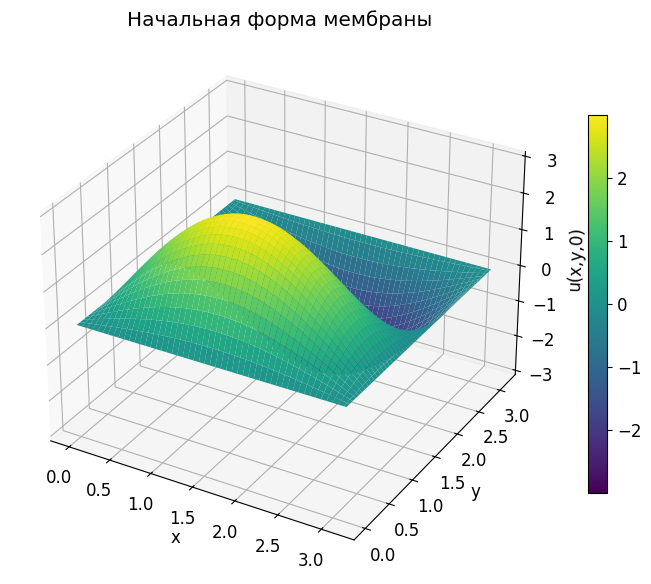

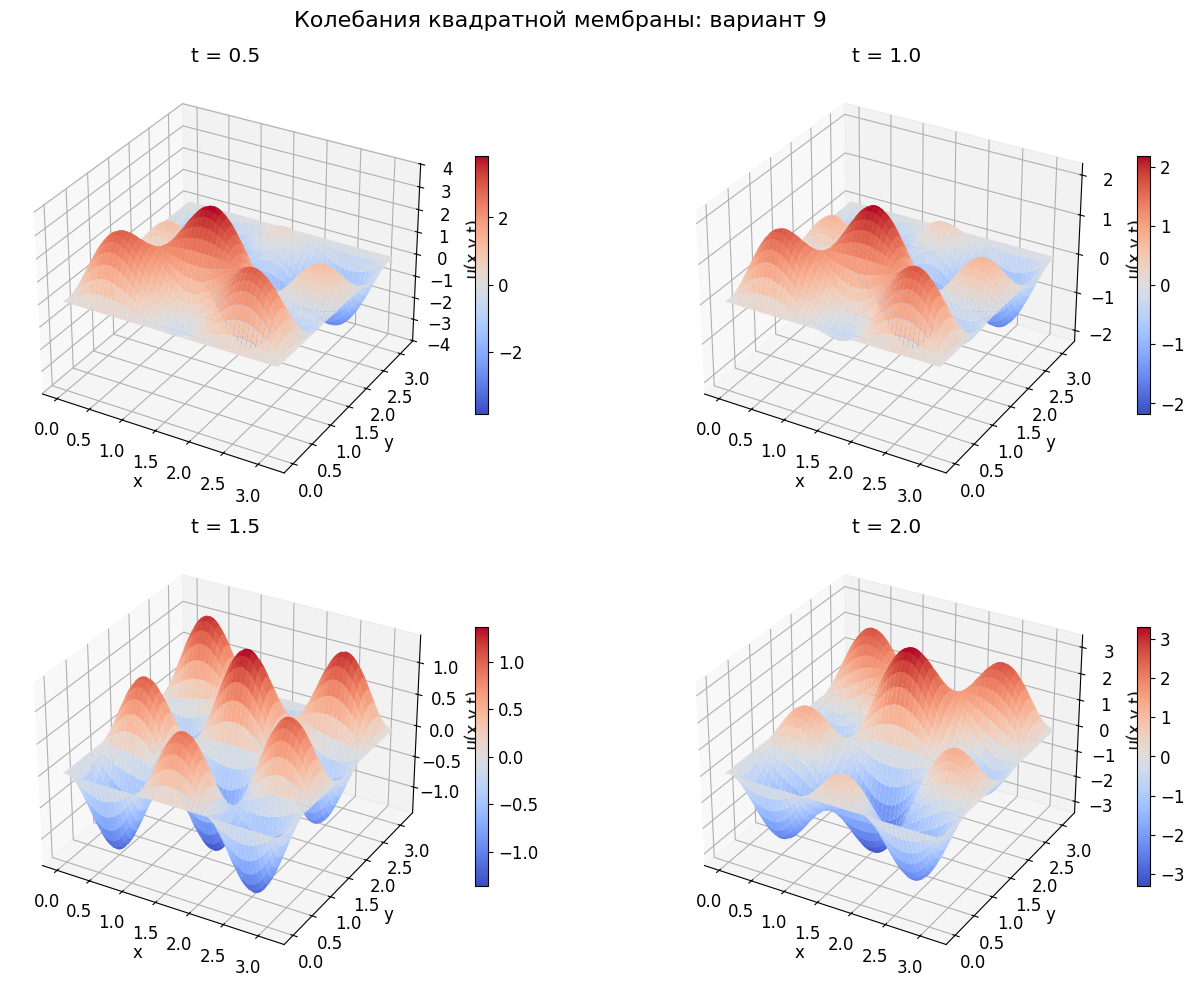

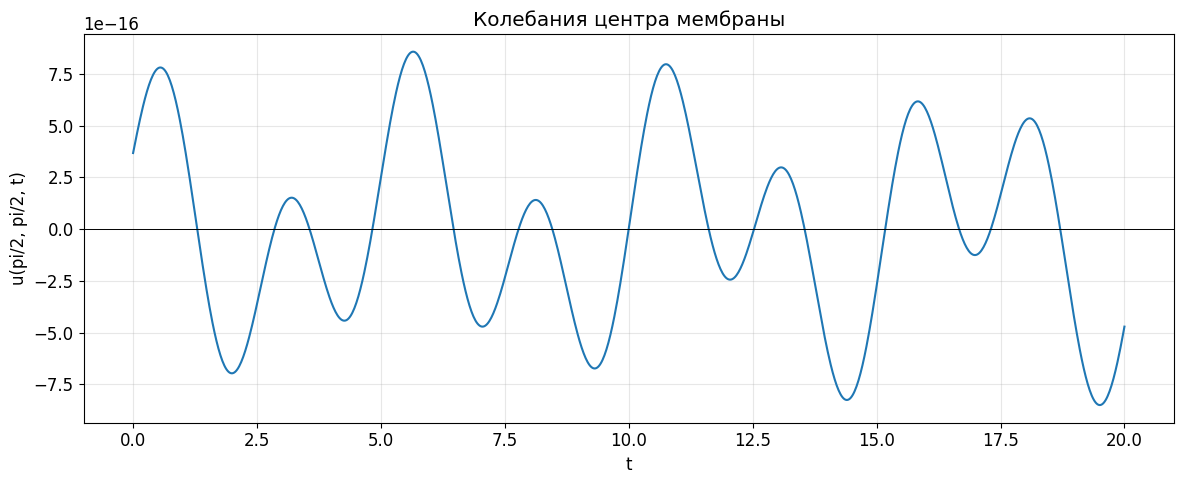


Максимальная амплитуда в центре: 0.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

print("=" * 70)
print("Лабораторная работа №9: колебания квадратной мембраны")
print("Вариант 9")
print("=" * 70)

# Параметры варианта 9
p = np.pi
q = np.pi
c = 0.5

print(f"Область: 0 < x < {p:.6f}, 0 < y < {q:.6f}")
print(f"Скорость волны: c = {c}")
print("Граничные условия: u(0,y,t)=u(pi,y,t)=u(x,0,t)=u(x,pi,t)=0")
print("Начальные условия:")
print("u(x,y,0) = 3 sin(x) sin(2y)")
print("u_t(x,y,0) = 5 sin(3x) sin(4y)")

# Частоты собственных мод
def omega(m, n):
    return c * np.sqrt(m**2 + n**2)

omega_12 = omega(1, 2)
omega_34 = omega(3, 4)

print(f"\nomega_12 = {omega_12:.6f}")
print(f"omega_34 = {omega_34:.6f}")

# Решение:
# u(x,y,t) = 3 cos(omega_12 t) sin(x) sin(2y) + (5/omega_34) sin(omega_34 t) sin(3x) sin(4y)
def u_membrane(x, y, t):
    term1 = 3 * np.cos(omega_12 * t) * np.sin(x) * np.sin(2 * y)
    term2 = (5 / omega_34) * np.sin(omega_34 * t) * np.sin(3 * x) * np.sin(4 * y)
    return term1 + term2

# Сетка
x = np.linspace(0, np.pi, 100)
y = np.linspace(0, np.pi, 100)
X, Y = np.meshgrid(x, y)

# Начальная форма мембраны
Z0 = u_membrane(X, Y, 0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z0, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y,0)')
ax.set_title('Начальная форма мембраны')
fig.colorbar(surf, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

# 4 графика для разных моментов времени
time_moments = [0.5, 1.0, 1.5, 2.0]

fig = plt.figure(figsize=(14, 10))
for idx, t_val in enumerate(time_moments, start=1):
    Z = u_membrane(X, Y, t_val)
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(x,y,t)')
    ax.set_title(f't = {t_val}')
    fig.colorbar(surf, ax=ax, shrink=0.6)

plt.suptitle('Колебания квадратной мембраны: вариант 9', fontsize=16)
plt.tight_layout()
plt.show()

# Колебания в центре мембраны
x_center = np.pi / 2
y_center = np.pi / 2
t_range = np.linspace(0, 20, 1000)
u_center = np.array([u_membrane(x_center, y_center, t) for t in t_range])

plt.figure(figsize=(12, 5))
plt.plot(t_range, u_center, linewidth=1.5)
plt.xlabel('t')
plt.ylabel('u(pi/2, pi/2, t)')
plt.title('Колебания центра мембраны')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.7)
plt.tight_layout()
plt.show()

print(f"\nМаксимальная амплитуда в центре: {np.max(np.abs(u_center)):.6f}")
